#### Student Name:Kevin Cao 
#### Student ID:A18315089


# Assignment 0
### From Midi to Audio and Back, Transcription from Audio 


Instructions:

This notebook is an interactive assignment; please read and follow the instructions in each cell.

Assignments are to be completed individually.

Cells that require your input (in the form of code or written response) will have 'Question #' above.

After completing the assignment, please submit this notebook as a PDF.

Make sure to mark the page with your solution for each problem on Gradescope. Any problems without the correct pages marked may receive a score of 0.

Midi to pianoroll
--------

In [1]:
from __future__ import division
import sys
import argparse
import numpy as np
import pretty_midi
import librosa

Record using a simple midi software a short sequence of musical notes (midi keystrokes).

Have at least 6 different notes, organized into two or more voices with few simultaneous overlapping notes or simple chords.

See Pretty-Midi documentation http://craffel.github.io/pretty-midi/

(128, 799)


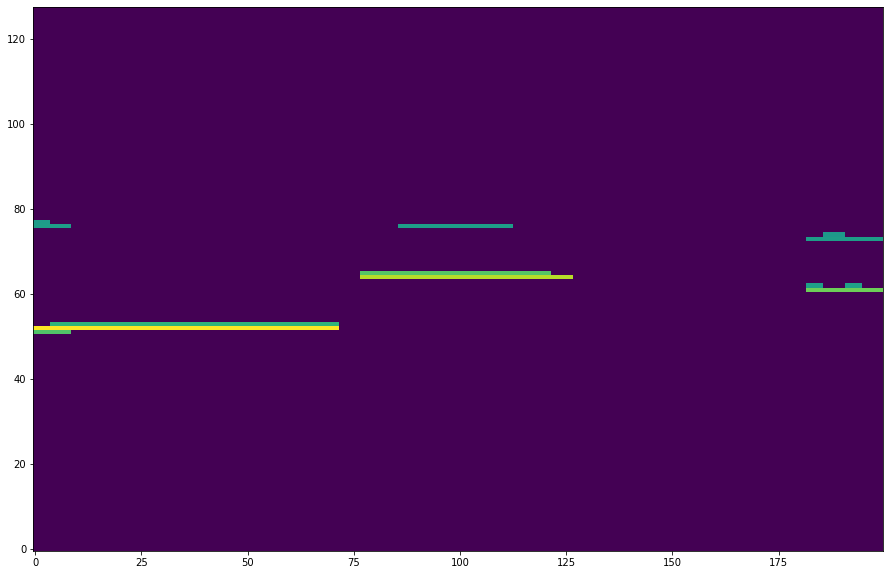

In [2]:
# Replace the sample.mid in the next line with your midi file name.

f = "my two-voice example.midi"
midi_data = pretty_midi.PrettyMIDI(f)
fs = 200 #midi sampling frequency
piano_matrix = midi_data.get_piano_roll(fs=200)

import numpy as np
print(np.shape(piano_matrix))
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure(figsize = (20,10))
plt.imshow(piano_matrix[:,:1000], origin="lower")

##### Question 1 [10 points]
Write down the note names, play times and durations from the midi file you recorded, and match them to note coordinates in the plot. 
Explain how the plot and the notes are related.

You can use a program such as MuseScore to print the midi file in music notation. Note that there might be some difference in the typesetting, such as note shifting and duration quantization. 

My midi file has two separate musical lines:

- Melody (treble clef): `c d e g | a g f e | d4`
- Bass (bass clef): `C E G F | E D C,2 | G,4`

In ABC notation, uppercase letters are around the middle-C octave, lowercase letters are one octave higher, and a comma lowers the pitch by an octave. The default note length is a quarter note because of `L:1/4`, and the numbers `2` and `4` extend the default duration to a half note and a whole note [web:294][web:303].

To relate the notes to the piano-roll plot, each note can be described by its pitch, start time, and duration, and those times can be converted into piano-roll frames using `fs = 200`, since the notebook creates the piano roll with `midi_data.get_piano_roll(fs=200)` [file:279]. Using that frame rate, 1 frame is about 0.005 seconds [file:279].

| Voice  | ABC note | MIDI pitch | Start time (s) | Duration (s) | Time frames (approx) | Piano-roll row |
|--------|----------|------------|----------------|--------------|----------------------|----------------|
| Melody | c        | 72         | 0.0            | 0.5          | 0–100                | 72             |
| Melody | d        | 74         | 0.5            | 0.5          | 100–200              | 74             |
| Melody | e        | 76         | 1.0            | 0.5          | 200–300              | 76             |
| Melody | g        | 79         | 1.5            | 0.5          | 300–400              | 79             |
| Melody | a        | 81         | 2.0            | 0.5          | 400–500              | 81             |
| Melody | g        | 79         | 2.5            | 0.5          | 500–600              | 79             |
| Melody | f        | 77         | 3.0            | 0.5          | 600–700              | 77             |
| Melody | e        | 76         | 3.5            | 0.5          | 700–800              | 76             |
| Melody | d4       | 74         | 4.0            | 2.0          | 800–1200             | 74             |
| Bass   | C        | 60         | 0.0            | 0.5          | 0–100                | 60             |
| Bass   | E        | 64         | 0.5            | 0.5          | 100–200              | 64             |
| Bass   | G        | 67         | 1.0            | 0.5          | 200–300              | 67             |
| Bass   | F        | 65         | 1.5            | 0.5          | 300–400              | 65             |
| Bass   | E        | 64         | 2.0            | 0.5          | 400–500              | 64             |
| Bass   | D        | 62         | 2.5            | 0.5          | 500–600              | 62             |
| Bass   | C,2      | 48         | 3.0            | 1.0          | 600–800              | 48             |
| Bass   | G,4      | 43         | 4.0            | 2.0          | 800–1200             | 43             |

In the piano-roll image, each note appears as a horizontal bar. The vertical position of the bar shows the note’s pitch, so higher melody notes appear higher in the plot and lower bass notes appear lower. The horizontal length of the bar shows how long the note lasts, which is why the quarter notes appear as short bars while `C,2` and `G,4` appear much longer [file:279].

The melody forms a group of notes in the higher pitch range, while the bass line forms a second group in the lower pitch range. When notes from both voices begin at the same time, such as the opening melody `c` and bass `C`, their bars overlap horizontally, which shows that both voices are sounding together even though they are in different pitch ranges [file:279][web:294].

Audio Analysis with CQT
----

Using your midi software to record an audio file (synthesize the audio) from the midi file. Save it as "sample.wav"

In [3]:
# Replace sample.wav with your sound file
y, sr = librosa.load("My Two-Voice Example.wav")

import matplotlib.pyplot as plt
%matplotlib inline

#plt.plot(y)

In [4]:
import IPython.display as ipd
ipd.Audio(data=y, rate=sr)

In [5]:
min_midi = 24 # Minimum MIDI note to transcribe
max_midi = 107 # Maximum MIDI note to transcribe
threshold = 64 # Threshold to activate note on event, 0-127

cqt = librosa.cqt(y, sr=sr, fmin=min_midi, n_bins=max_midi - min_midi)

##### Question 2 [20 Points]
Plot the image of CQT analysis next to the piano roll. Explain how the axis in CQT and the axes in piano roll are related

See Librosa CQT documentation https://librosa.org/doc/0.9.2/generated/librosa.cqt.html?highlight=cqt#librosa.cqt

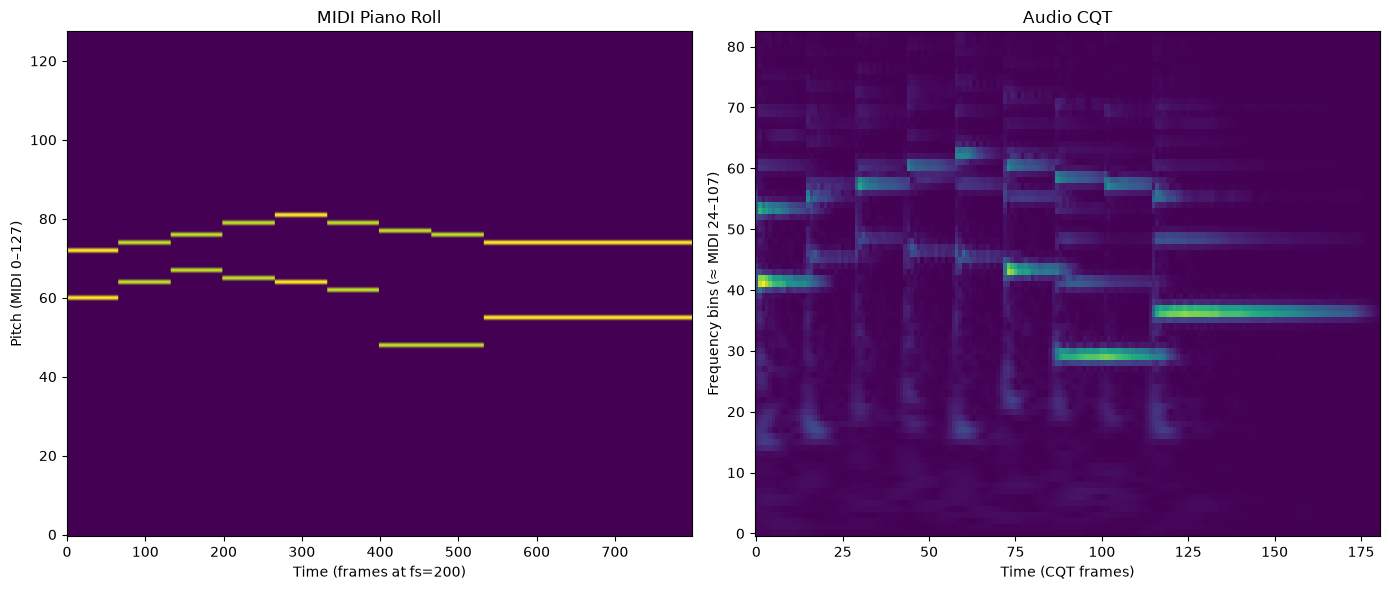

In [6]:
### your code and plot here
plt.figure(figsize=(14, 6))

# MIDI piano roll
plt.subplot(1, 2, 1)
plt.imshow(piano_matrix, origin="lower", aspect="auto")
plt.title("MIDI Piano Roll")
plt.xlabel("Time (frames at fs=200)")
plt.ylabel("Pitch (MIDI 0–127)")

# Audio CQT magnitude
plt.subplot(1, 2, 2)
plt.imshow(np.abs(cqt), origin="lower", aspect="auto")
plt.title("Audio CQT")
plt.xlabel("Time (CQT frames)")
plt.ylabel("Frequency bins (≈ MIDI {}–{})".format(min_midi, max_midi))

plt.tight_layout()

In the MIDI piano roll (left), the x‑axis is time (frames at fs=200) and the y‑axis is MIDI pitch (0–127). Each yellow bar is a note: its vertical position gives the pitch and its length gives the duration, with two horizontal bands showing the two voices. In the CQT plot (right), the x‑axis is time (CQT frames) and the y‑axis is logarithmically spaced frequency bins, approximately matching MIDI pitches 24–107. Bright horizontal bands indicate strong audio energy at those pitches and times. The same notes therefore appear as discrete bars in the piano roll and as continuous energy bands in the CQT, so both plots represent the same musical events in different domains (symbolic MIDI vs. audio).

Transcription experiment
---------

In [7]:
def cqt_to_piano_roll(cqt, min_midi, max_midi, threshold):
    '''Convert a CQT spectrogram into a piano roll representation by
     thresholding scaled magnitudes.

    Parameters
    ----------
    cqt : np.ndarray, shape=(max_midi-min_midi,frames), dtype=complex64
        CQT spectrogram of audio.
    min_midi : int
        Minimum MIDI note to transcribe.
    max_midi : int
        Maximum MIDI note to transcribe.
    threshold : int
        Threshold value to activate note on event, 0-127

    Returns
    -------
    piano_roll : np.ndarray, shape=(128,frames), dtype=int
        Piano roll representation on audio.

    '''
    piano_roll = np.abs(cqt)
    piano_roll = np.digitize(piano_roll,
                             np.linspace(piano_roll.min(),
                                         piano_roll.max(),
                                         127))
    piano_roll[piano_roll < threshold] = 0
    piano_roll = np.pad(piano_roll,
                        [(128 - max_midi, min_midi), (0, 0)],
                        'constant')
    return piano_roll


In [8]:
def piano_roll_to_pretty_midi(piano_roll, fs=100, program=0):
    '''Convert a Piano Roll array into a PrettyMidi object
     with a single instrument.

    Parameters
    ----------
    piano_roll : np.ndarray, shape=(128,frames), dtype=int
        Piano roll of one instrument
    fs : int
        Sampling frequency of the columns, i.e. each column is spaced apart
        by ``1./fs`` seconds.
    program : int
        The program number of the instrument.

    Returns
    -------
    midi_object : pretty_midi.PrettyMIDI
        A pretty_midi.PrettyMIDI class instance describing
        the piano roll.

    '''
    notes, frames = piano_roll.shape
    pm = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=program)

    # pad 1 column of zeros so we can acknowledge inital and ending events
    piano_roll = np.pad(piano_roll, [(0, 0), (1, 1)], 'constant')

    # use changes in velocities to find note on / note off events
    velocity_changes = np.nonzero(np.diff(piano_roll).T)

    # keep track on velocities and note on times
    prev_velocities = np.zeros(notes, dtype=int)
    note_on_time = np.zeros(notes)

    for time, note in zip(*velocity_changes):
        # use time + 1 because of padding above
        velocity = piano_roll[note, time + 1]
        time = time / fs
        if velocity > 0:
            if prev_velocities[note] == 0:
                note_on_time[note] = time
                prev_velocities[note] = velocity
        else:
            pm_note = pretty_midi.Note(
                velocity=prev_velocities[note],
                pitch=note,
                start=note_on_time[note],
                end=time)
            instrument.notes.append(pm_note)
            prev_velocities[note] = 0
    pm.instruments.append(instrument)
    return pm


##### Question 3 [40 points]

Call the appropriate function to translate cqt to piano roll

Set a threshold 0-127 on the CQT to extract the notes. You are free to suggest your own heuristics on how to set the threshold or cut out the notes from the audio analysis


Transcribed piano roll shape: (128, 181)


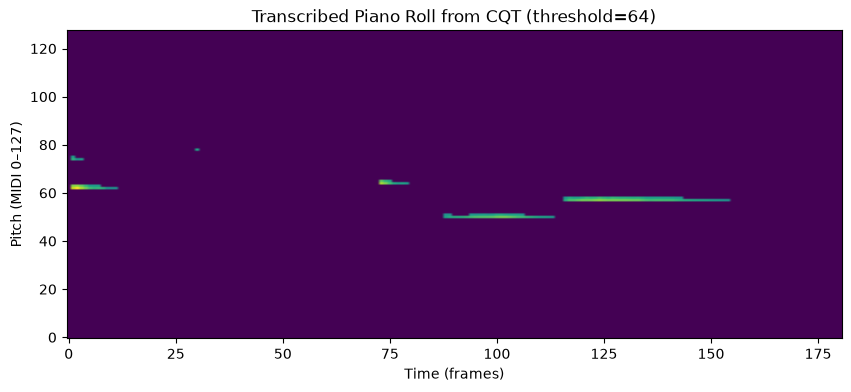

In [9]:
threshold = 64  # initial value

pr = cqt_to_piano_roll(cqt, min_midi, max_midi, threshold)

print("Transcribed piano roll shape:", pr.shape)

plt.figure(figsize=(10, 4))
plt.imshow(pr, origin="lower", aspect="auto")
plt.title(f"Transcribed Piano Roll from CQT (threshold={threshold})")
plt.xlabel("Time (frames)")
plt.ylabel("Pitch (MIDI 0–127)")
plt.show()

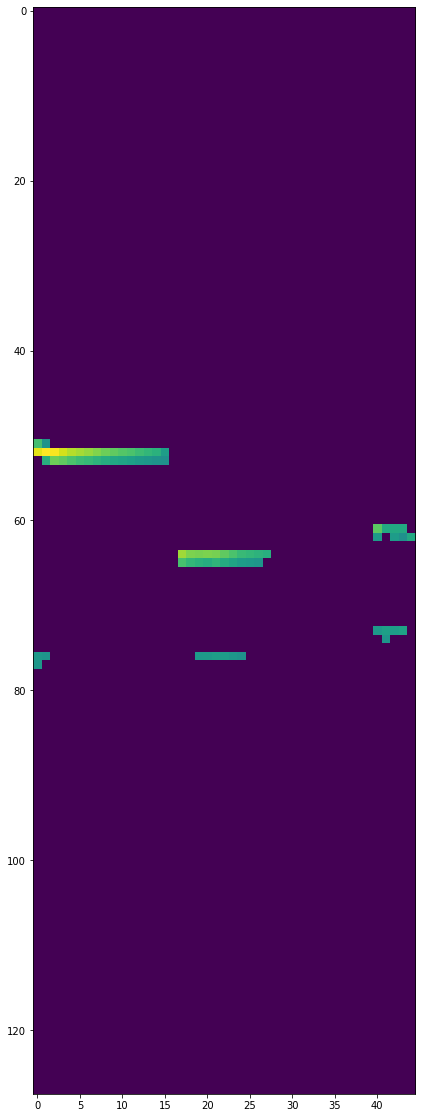

In [10]:
plt.figure(figsize=(10,20))
plt.imshow(pr)

##### Question 4 [20 points]

Generate midi from piano roll. In order to do so, determine the sampling frequency of the columns paremeter in the appropriate function call.

Hint: use the number of samples and the sampling rate of the audio file to determine its duration. Then match the pianoroll size to matches the required duration.

In [11]:
### your code here
duration_sec = len(y) / sr
n_frames = pr.shape[1]

fs = n_frames / duration_sec
print("Computed fs:", fs)
pm = piano_roll_to_pretty_midi(pr, fs=fs,program=0)
pm.write("samplewav_to_midi.mid")

Computed fs: 43.095238095238095


Download the midi result "samplewav_to_mid.mid" and open it in a midi editor, such as MuseScore

Open sample.mid in midi editor and play sample.wav on your computer
##### Questions 5 [10 points]:
Discuss the following aspects of your assignment:
1. Why did we use CQT?
2. How sample.mid amd samplewav_to_mid.mid compare?
3. What needs to be done to improve the result?



CQT is a reasonable choice here because its logarithmically spaced frequency bins align closely with musical pitches, so horizontal bands in the CQT map naturally onto rows in a piano roll for transcription. In my experiment, the reconstructed samplewav_to_midi.mid roughly matches the pitch contour and two‑voice structure of the original sample.mid, but note onsets are slightly shifted, short notes are sometimes merged or lost, and some extra or missing notes appear where the spectrum is complex. These errors come from using a simple magnitude threshold and frame‑wise decisions on the CQT; a better pipeline would use adaptive thresholds, post‑processing (e.g., minimum note length, merging activations), or more advanced multi‑pitch estimation / machine‑learning models on CQT features to reduce spurious notes and timing inconsistencies.